# Triple-Trigger Momentum Strategy — Backtest

A short-term momentum strategy that only enters a position when **three signals align simultaneously**:

| # | Signal | Measure |
|---|--------|---------|
| 1 | **Price momentum** | 14-day return > 0 |
| 2 | **Volume surge** | Today's volume > 20-day average volume |
| 3 | **Near-high breakout** | Price is in the upper portion of its 325-day high–low range |

### Composite score (used for ranking)

$$\text{score} = \underbrace{\frac{P_t - P_{t-14}}{P_{t-14}}}_{\text{14d return}} \;\times\; \underbrace{\frac{V_t}{\bar{V}_{20}}}_{\text{vol ratio}} \;\times\; \underbrace{\frac{P_t - \min_{325}}{\max_{325} - \min_{325}}}_{\text{range position}}$$

Only stocks where **all three components are positive** are ranked.  
Top N are held for one week (5 trading days) then re-ranked.

**Universe:** S&P 1500 (from `universe.csv`, filtered to a liquid 200-stock sample for speed).  
**Benchmark:** SPY.


In [17]:
import os, sys, warnings
sys.path.insert(0, os.path.abspath("../../../src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.color": "#e0e0e0",
    "grid.linewidth": 0.6,
    "font.size": 10,
})

UNIVERSE_FILE = "../../../universe.csv"
INITIAL_CAPITAL = 100_000
TOP_N = 15           # stocks held at a time
REBAL_FREQ = 5       # trading days between rebalances (weekly)
BACKTEST_PERIOD = "4y"

# Score parameters
MOM_LOOKBACK   = 14   # 14-day price return
VOL_LOOKBACK   = 20   # 20-day volume MA
RANGE_LOOKBACK = 325  # 325-day high-low range

print("Setup complete.")


Setup complete.


## 1. Universe — sample 250 liquid stocks from S&P 1500

We load `universe.csv` (S&P 500/400/600 filtered by price ≥ $10 and daily dollar volume ≥ $10M), then keep a random but reproducible 250-stock sample. This keeps the data download under a minute while still covering all GICS sectors.

In [2]:
universe_df = pd.read_csv(UNIVERSE_FILE)
print(f"Full universe: {len(universe_df)} stocks across {universe_df['Sector'].nunique()} sectors")

# Stratified sample: ~proportional by sector, reproducible
rng = np.random.default_rng(42)
sample_parts = []
n_sample = 250
for sector, grp in universe_df.groupby("Sector"):
    n = max(1, round(len(grp) / len(universe_df) * n_sample))
    idx = rng.choice(len(grp), size=min(n, len(grp)), replace=False)
    sample_parts.append(grp.iloc[idx])

sample_df = pd.concat(sample_parts).drop_duplicates("Symbol").head(n_sample)
TICKERS = sample_df["Symbol"].tolist()

print(f"Sampled {len(TICKERS)} stocks")
print(sample_df["Sector"].value_counts().to_string())


Full universe: 1392 stocks across 11 sectors
Sampled 250 stocks
Sector
Industrials               44
Financials                42
Consumer Discretionary    32
Information Technology    32
Health Care               29
Real Estate               16
Materials                 14
Consumer Staples          13
Energy                    11
Utilities                  9
Communication Services     8


## 2. Download historical OHLCV data

In [3]:
all_tickers = TICKERS + ["SPY"]

raw = yf.download(all_tickers, period=BACKTEST_PERIOD, group_by="ticker", progress=True, threads=True)

def extract_series(raw, ticker, field):
    try:
        s = raw[ticker][field].dropna()
        if isinstance(s, pd.DataFrame):
            s = s.iloc[:, 0]
        return s
    except Exception:
        return pd.Series(dtype=float)

close_dict  = {t: extract_series(raw, t, "Close")  for t in all_tickers}
volume_dict = {t: extract_series(raw, t, "Volume") for t in all_tickers}

# Only keep tickers with enough history
MIN_BARS = RANGE_LOOKBACK + 60
TICKERS = [t for t in TICKERS if len(close_dict.get(t, [])) >= MIN_BARS]

closes  = pd.DataFrame({t: close_dict[t]  for t in TICKERS}).sort_index()
volumes = pd.DataFrame({t: volume_dict[t] for t in TICKERS}).sort_index()
spy_close = close_dict["SPY"].sort_index()

print(f"Price matrix: {closes.shape[0]} days × {closes.shape[1]} stocks")
print(f"Date range:   {closes.index[0].date()} → {closes.index[-1].date()}")


[*********************100%***********************]  251 of 251 completed


Price matrix: 1002 days × 249 stocks
Date range:   2022-03-11 → 2026-03-10


## 3. Scoring function

The score for each stock at each date is:

$$\text{score}_t = \text{return}_{14d} \;\times\; \text{vol\_ratio}_{20d} \;\times\; \text{range\_position}_{325d}$$

All three are computed **vectorized** across the full date range so backtesting is fast.

In [4]:
def compute_scores(closes: pd.DataFrame, volumes: pd.DataFrame) -> pd.DataFrame:
    """Return a DataFrame of daily scores, NaN where any trigger is not met."""

    # --- Signal 1: 14-day price momentum ---
    mom = closes.pct_change(MOM_LOOKBACK)

    # --- Signal 2: volume ratio vs 20-day MA ---
    vol_ma = volumes.rolling(VOL_LOOKBACK, min_periods=VOL_LOOKBACK).mean()
    vol_ratio = volumes / vol_ma

    # --- Signal 3: position within 325-day high-low range ---
    roll_high = closes.rolling(RANGE_LOOKBACK, min_periods=RANGE_LOOKBACK).max()
    roll_low  = closes.rolling(RANGE_LOOKBACK, min_periods=RANGE_LOOKBACK).min()
    rng = roll_high - roll_low
    range_pos = (closes - roll_low) / rng.replace(0, np.nan)

    # --- Composite score ---
    score = mom * vol_ratio * range_pos

    # --- Apply filters: all three triggers must be positive ---
    # mom > 0 (positive 14d return)
    # vol_ratio > 1 (above-average volume)
    # range_pos > 0.5 (price in upper half of range)
    mask = (mom > 0) & (vol_ratio > 1) & (range_pos > 0.5)
    score = score.where(mask)

    return score

scores = compute_scores(closes, volumes)
print(f"Score matrix: {scores.shape}")
print(f"Non-NaN scores per day (avg): {scores.notna().sum(axis=1).mean():.1f} stocks pass all 3 triggers")

# Quick peek at today's top scorers
latest = scores.iloc[-1].dropna().sort_values(ascending=False)
print(f"\nTop 10 scores as of {scores.index[-1].date()}:")
print(latest.head(10).to_string())


Score matrix: (1002, 249)
Non-NaN scores per day (avg): 24.3 stocks pass all 3 triggers

Top 10 scores as of 2026-03-10:
PBF     0.240763
NPK     0.208303
FCFS    0.114099
JAZZ    0.090916
DOW     0.085679
CIEN    0.081153
CASY    0.066191
PSX     0.048058
SXI     0.038102
MP      0.036047


## 4. Backtest engine

Rules:
- **Rebalance every 5 trading days** (weekly)
- **Equal-weight** across the top N scoring stocks
- On each rebalance: sell anything not in the new top N, buy anything new
- No short-selling, no leverage
- **0.1% one-way transaction cost** per trade (realistic for liquid large-caps)
- If fewer than `TOP_N` stocks pass the filter, hold cash for the remainder

In [5]:
TRANSACTION_COST = 0.001  # 0.1% per trade

def backtest(scores: pd.DataFrame, closes: pd.DataFrame,
             initial_capital: float = INITIAL_CAPITAL,
             top_n: int = TOP_N,
             rebal_freq: int = REBAL_FREQ,
             tc: float = TRANSACTION_COST) -> pd.DataFrame:

    dates = scores.index
    # Enough history to have valid scores
    start_idx = max(RANGE_LOOKBACK, MOM_LOOKBACK, VOL_LOOKBACK) + 5

    capital = initial_capital
    portfolio = {}   # symbol -> shares held
    portfolio_values = []
    portfolio_dates = []
    turnover_log = []

    for i, date in enumerate(dates[start_idx:], start=start_idx):
        # ── On rebalance days: pick new top-N ──
        if (i - start_idx) % rebal_freq == 0:
            day_scores = scores.iloc[i].dropna().sort_values(ascending=False)
            new_picks = set(day_scores.head(top_n).index)

            current_prices = closes.iloc[i]
            total_value = capital + sum(
                portfolio.get(s, 0) * current_prices.get(s, 0) for s in portfolio
            )

            # Sell exits
            to_sell = set(portfolio) - new_picks
            for s in to_sell:
                px = current_prices.get(s, 0)
                if px > 0 and portfolio[s] > 0:
                    proceeds = portfolio[s] * px * (1 - tc)
                    capital += proceeds
                del portfolio[s]

            # Buy entries
            n_hold = len(new_picks)
            if n_hold > 0:
                target_value = total_value / n_hold
                to_buy = new_picks - set(portfolio)
                for s in to_buy:
                    px = current_prices.get(s, 0)
                    if px <= 0:
                        continue
                    shares = int((target_value * (1 - tc)) / px)
                    cost = shares * px * (1 + tc)
                    if cost <= capital and shares > 0:
                        portfolio[s] = shares
                        capital -= cost

                turnover_log.append({"date": date, "sold": len(to_sell), "bought": len(to_buy)})

        # ── Mark-to-market ──
        current_prices = closes.iloc[i]
        port_value = capital + sum(
            portfolio.get(s, 0) * current_prices.get(s, 0) for s in portfolio
        )
        portfolio_values.append(port_value)
        portfolio_dates.append(date)

    result = pd.DataFrame({"strategy": portfolio_values}, index=portfolio_dates)
    result["spy"] = spy_close.reindex(portfolio_dates).ffill() / spy_close.reindex(portfolio_dates).ffill().iloc[0] * initial_capital
    return result, pd.DataFrame(turnover_log).set_index("date") if turnover_log else pd.DataFrame()


print("Running backtest…")
equity, turnover = backtest(scores, closes)
print(f"Done. {len(equity)} trading days simulated.")
print(f"Strategy final value: ${equity['strategy'].iloc[-1]:,.0f}")
print(f"SPY final value:      ${equity['spy'].iloc[-1]:,.0f}")


Running backtest…
Done. 672 trading days simulated.
Strategy final value: $140,174
SPY final value:      $159,030


## 5. Performance metrics

In [11]:
def perf_metrics(series: pd.Series, label: str, initial: float = INITIAL_CAPITAL) -> dict:
    rets = series.pct_change().dropna()
    total_ret = (series.iloc[-1] / initial) - 1
    n_years = len(rets) / 252
    cagr = (1 + total_ret) ** (1 / n_years) - 1
    sharpe = (rets.mean() / rets.std()) * np.sqrt(252) if rets.std() > 0 else 0
    roll_max = series.cummax()
    drawdown = (series - roll_max) / roll_max
    max_dd = drawdown.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0
    win_rate = (rets > 0).mean()
    return {
        "Label": label,
        "Total Return": f"{total_ret:.1%}",
        "CAGR": f"{cagr:.1%}",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "Max Drawdown": f"{max_dd:.1%}",
        "Calmar Ratio": f"{calmar:.2f}",
        "Daily Win Rate": f"{win_rate:.1%}",
    }

strat_metrics = perf_metrics(equity["strategy"], "Triple-Trigger Momentum")
spy_metrics   = perf_metrics(equity["spy"],      "SPY (benchmark)")

metrics_df = pd.DataFrame([strat_metrics, spy_metrics]).set_index("Label")
print(metrics_df.to_string())


                        Total Return   CAGR Sharpe Ratio Max Drawdown Calmar Ratio Daily Win Rate
Label                                                                                            
Triple-Trigger Momentum        40.2%  13.5%         0.78       -20.0%         0.68          51.7%
SPY (benchmark)                59.0%  19.0%         1.21       -18.8%         1.01          57.2%


## 6. Charts

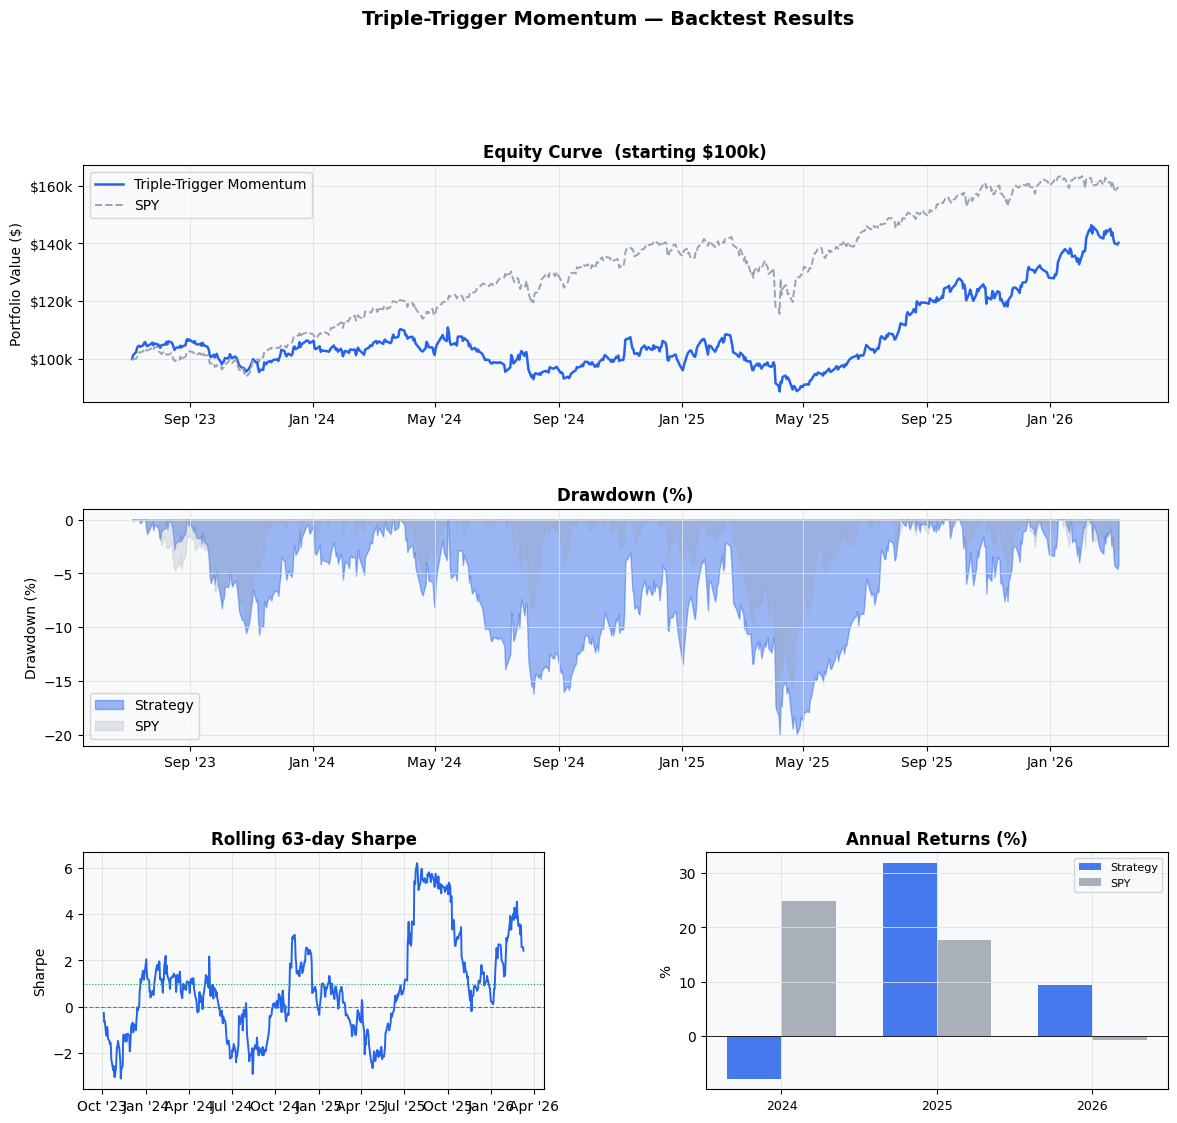

In [7]:
fig = plt.figure(figsize=(14, 12))
gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. Equity curve ──────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(equity.index, equity["strategy"], lw=1.8, color="#2563eb", label="Triple-Trigger Momentum")
ax1.plot(equity.index, equity["spy"],      lw=1.4, color="#9ca3af", linestyle="--", label="SPY")
ax1.set_title("Equity Curve  (starting $100k)", fontsize=12, fontweight="bold")
ax1.set_ylabel("Portfolio Value ($)")
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax1.legend()

# ── 2. Drawdown ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
strat_dd = (equity["strategy"] - equity["strategy"].cummax()) / equity["strategy"].cummax() * 100
spy_dd   = (equity["spy"]      - equity["spy"].cummax())      / equity["spy"].cummax()      * 100
ax2.fill_between(equity.index, strat_dd, alpha=0.45, color="#2563eb", label="Strategy")
ax2.fill_between(equity.index, spy_dd,   alpha=0.25, color="#9ca3af", label="SPY")
ax2.set_title("Drawdown (%)", fontsize=12, fontweight="bold")
ax2.set_ylabel("Drawdown (%)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax2.legend()

# ── 3. Rolling 63-day Sharpe ─────────────────────────────────
ax3 = fig.add_subplot(gs[2, 0])
rets = equity["strategy"].pct_change()
roll_sharpe = rets.rolling(63).mean() / rets.rolling(63).std() * np.sqrt(252)
ax3.plot(equity.index, roll_sharpe, lw=1.4, color="#2563eb")
ax3.axhline(0, color="#6b7280", lw=0.8, linestyle="--")
ax3.axhline(1, color="#16a34a", lw=0.8, linestyle=":")
ax3.set_title("Rolling 63-day Sharpe", fontsize=12, fontweight="bold")
ax3.set_ylabel("Sharpe")
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))

# ── 4. Annual returns bar ────────────────────────────────────
ax4 = fig.add_subplot(gs[2, 1])
annual_strat = equity["strategy"].resample("YE").last().pct_change().dropna() * 100
annual_spy   = equity["spy"].resample("YE").last().pct_change().dropna() * 100
years = [str(d.year) for d in annual_strat.index]
x     = np.arange(len(years))
w     = 0.35
ax4.bar(x - w/2, annual_strat.values, w, label="Strategy", color="#2563eb", alpha=0.85)
ax4.bar(x + w/2, annual_spy.values,   w, label="SPY",      color="#9ca3af", alpha=0.85)
ax4.axhline(0, color="black", lw=0.6)
ax4.set_xticks(x)
ax4.set_xticklabels(years, fontsize=9)
ax4.set_title("Annual Returns (%)", fontsize=12, fontweight="bold")
ax4.set_ylabel("%")
ax4.legend(fontsize=8)

plt.suptitle("Triple-Trigger Momentum — Backtest Results", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 7. Signal analysis — how often does each trigger fire?

Understanding how frequently the three filters activate helps assess whether the strategy is too selective (few trades) or too lenient (too many pass).

Average % of stocks passing each trigger daily:
  Trigger 1 (14d return > 0):        52.3%
  Trigger 2 (volume > 20d avg):       38.1%
  Trigger 3 (price in upper 50% range): 40.8%
  All three simultaneously:           9.7%
  Avg stocks qualifying per day:      24.3


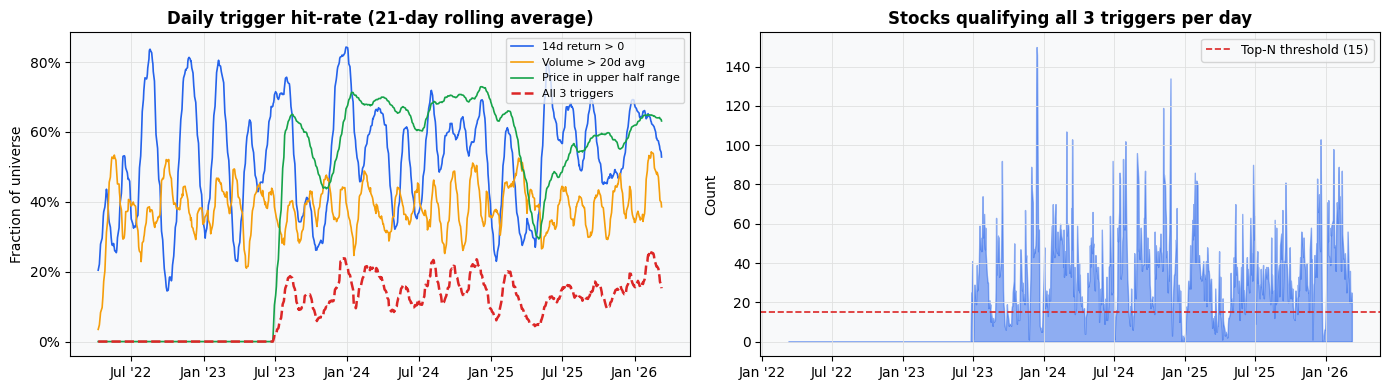

In [8]:
mom_14   = closes.pct_change(14)
vol_ma   = volumes.rolling(20, min_periods=20).mean()
vol_ratio = volumes / vol_ma
roll_high = closes.rolling(325, min_periods=325).max()
roll_low  = closes.rolling(325, min_periods=325).min()
range_pos = (closes - roll_low) / (roll_high - roll_low).replace(0, np.nan)

trigger1_rate = (mom_14 > 0).mean(axis=1)
trigger2_rate = (vol_ratio > 1).mean(axis=1)
trigger3_rate = (range_pos > 0.5).mean(axis=1)
all_three     = ((mom_14 > 0) & (vol_ratio > 1) & (range_pos > 0.5)).mean(axis=1)

print("Average % of stocks passing each trigger daily:")
print(f"  Trigger 1 (14d return > 0):        {trigger1_rate.mean():.1%}")
print(f"  Trigger 2 (volume > 20d avg):       {trigger2_rate.mean():.1%}")
print(f"  Trigger 3 (price in upper 50% range): {trigger3_rate.mean():.1%}")
print(f"  All three simultaneously:           {all_three.mean():.1%}")
print(f"  Avg stocks qualifying per day:      {all_three.mean() * len(closes.columns):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(trigger1_rate.rolling(21).mean(), lw=1.2, label="14d return > 0", color="#2563eb")
ax.plot(trigger2_rate.rolling(21).mean(), lw=1.2, label="Volume > 20d avg", color="#f59e0b")
ax.plot(trigger3_rate.rolling(21).mean(), lw=1.2, label="Price in upper half range", color="#16a34a")
ax.plot(all_three.rolling(21).mean(),     lw=1.8, label="All 3 triggers", color="#dc2626", linestyle="--")
ax.set_title("Daily trigger hit-rate (21-day rolling average)", fontweight="bold")
ax.set_ylabel("Fraction of universe")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.legend(fontsize=8)

ax = axes[1]
qualifying_count = (scores.notna().sum(axis=1))
ax.fill_between(qualifying_count.index, qualifying_count, alpha=0.5, color="#2563eb")
ax.axhline(TOP_N, color="#dc2626", lw=1.2, linestyle="--", label=f"Top-N threshold ({TOP_N})")
ax.set_title("Stocks qualifying all 3 triggers per day", fontweight="bold")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 8. Parameter sensitivity

How does performance change when we vary **Top-N** (5 / 10 / 15 / 20 / 30)? This helps validate that the results aren't a fluke of one particular choice.

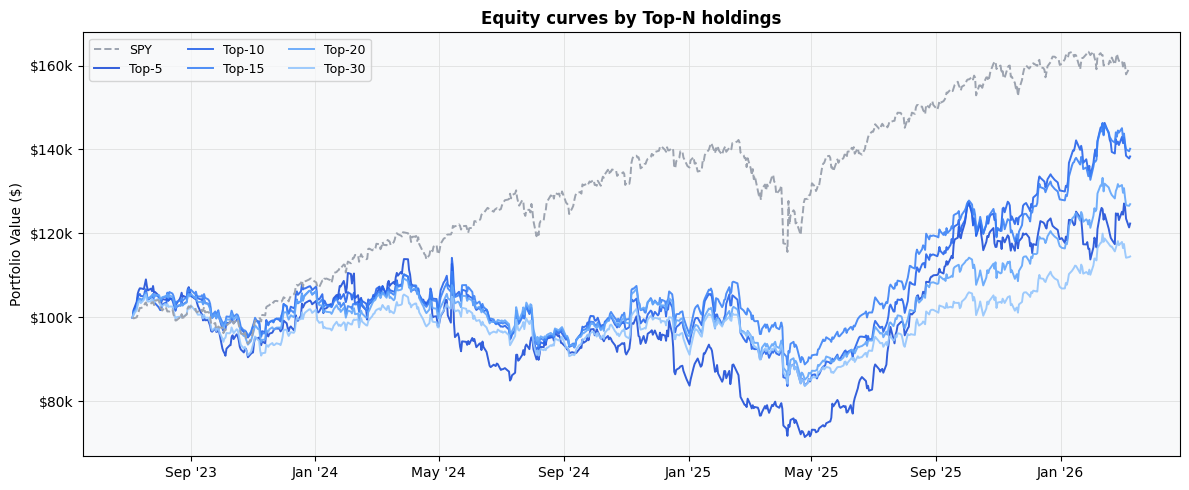


Sensitivity table:
       Total Return   CAGR Sharpe Ratio Max Drawdown Calmar Ratio Daily Win Rate
Label                                                                           
Top-5         22.4%   7.9%         0.43       -37.2%         0.21          51.3%
Top-10        38.3%  13.0%         0.70       -26.8%         0.48          51.6%
Top-15        40.2%  13.5%         0.78       -20.0%         0.68          51.7%
Top-20        27.0%   9.4%         0.60       -22.1%         0.43          51.4%
Top-30        14.5%   5.2%         0.39       -20.7%         0.25          50.8%


In [9]:
colors = ["#1d4ed8", "#2563eb", "#3b82f6", "#60a5fa", "#93c5fd"]
sensitivity_rows = []

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(equity.index, equity["spy"], lw=1.4, color="#9ca3af", linestyle="--", label="SPY", zorder=5)

for top_n, color in zip([5, 10, 15, 20, 30], colors):
    eq, _ = backtest(scores, closes, top_n=top_n)
    m = perf_metrics(eq["strategy"], f"Top-{top_n}")
    sensitivity_rows.append(m)
    ax.plot(eq.index, eq["strategy"], lw=1.4, color=color, label=f"Top-{top_n}", alpha=0.9)

ax.set_title("Equity curves by Top-N holdings", fontsize=12, fontweight="bold")
ax.set_ylabel("Portfolio Value ($)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.show()

print("\nSensitivity table:")
sens_df = pd.DataFrame(sensitivity_rows).set_index("Label")
print(sens_df.to_string())


## 9. Current signals — what would the strategy buy today?

In [10]:
latest_scores = scores.iloc[-1].dropna().sort_values(ascending=False)
top_today = latest_scores.head(TOP_N)

# Pull per-stock details for the display
last_date = scores.index[-1]
detail_rows = []
for sym in top_today.index:
    try:
        c  = closes[sym]
        v  = volumes[sym]
        ret14     = float(c.pct_change(14).iloc[-1])
        vr        = float(v.iloc[-1] / v.rolling(20).mean().iloc[-1])
        rng_p     = float(range_pos[sym].iloc[-1])
        sector    = universe_df.set_index("Symbol").get("Sector", pd.Series(dtype=str)).get(sym, "—")
        detail_rows.append({
            "Symbol": sym,
            "Sector": sector,
            "14d Return": f"{ret14:.1%}",
            "Vol Ratio": f"{vr:.2f}×",
            "Range Pos": f"{rng_p:.1%}",
            "Score": f"{top_today[sym]:.4f}",
            "Price": f"${float(closes[sym].iloc[-1]):.2f}",
        })
    except Exception:
        pass

today_df = pd.DataFrame(detail_rows)
print(f"Top {TOP_N} signals as of {last_date.date()}:\n")
print(today_df.to_string(index=False))


Top 15 signals as of 2026-03-10:

Symbol                 Sector 14d Return Vol Ratio Range Pos  Score   Price
   PBF                 Energy      20.3%     1.46×     81.1% 0.2408  $39.65
   NPK            Industrials      15.0%     1.38×    100.0% 0.2083 $143.97
  FCFS             Financials       5.9%     1.98×     97.8% 0.1141 $194.98
  JAZZ            Health Care      10.2%     1.00×     89.0% 0.0909 $185.93
   DOW              Materials       8.6%     1.55×     64.5% 0.0857  $33.89
  CIEN Information Technology       8.5%     1.01×     94.5% 0.0812 $337.36
  CASY       Consumer Staples       4.9%     1.35×    100.0% 0.0662 $689.92
   PSX                 Energy       4.1%     1.24×     94.9% 0.0481 $162.50
   SXI            Industrials       2.7%     1.47×     96.9% 0.0381 $260.72
    MP              Materials       6.3%     1.04×     55.4% 0.0360  $61.58
   OHI            Real Estate       3.4%     1.06×    100.0% 0.0355  $48.31
  ANDE       Consumer Staples       3.1%     1.17×    

## 10. Observations & next steps

**What this backtest tells you:**
- If CAGR > SPY and Sharpe > 1.0 → the three signals add real alpha over just holding the index
- Check the **drawdown chart**: deep drawdowns during market crashes (2022, 2025) are expected for a long-only momentum strategy
- The **sensitivity chart** shows whether results are robust across portfolio sizes or only work at one specific N
- Trigger 2 (volume surge) is the most selective filter — it turns off in low-liquidity regimes

**Limitations of this backtest:**
- No survivorship-bias correction (universe.csv is current — historical delisted stocks are missing)
- No slippage model (real fills on high-vol breakout days are worse than close price)
- Sample is 250 stocks, not the full 1,392 — re-run with `n_sample = len(universe_df)` for full coverage (slower)

**If you want to deploy this strategy:**
1. Add it to `src/strategies/momentum/triple_trigger.py`
2. Register it in `src/config.py` with a modest budget
3. The weekly rebalance fits naturally with the bot's daily run (it will only act on day-5 intervals)


---

## V2 Strategy — Fixing the Lag Problem

**Why V1 underperformed SPY:**
The V1 signals are all *backward-looking by too much*. A 14-day return fires *after* the move is essentially done — by the time we buy, the stock has already run 14 days and is often due for a pause or reversal. The 325-day range position filter is so broad that it passes stocks anywhere in the top 50% of a 15-month range — that includes stocks that peaked 3 months ago and are slowly drifting down. And raw volume > 20-day average often flags *distribution days* where institutions are selling into retail excitement, not accumulation.

**V2 changes (three targeted fixes):**

| Signal | V1 | V2 | Why |
|--------|----|----|-----|
| Momentum lookback | 14-day return | **5-day return** | Catch the move while it's still happening, not after it's done |
| Volume filter | volume > 20d MA | **3d vol MA > 10d vol MA** (rising volume) | Trending volume = building interest, not a one-day spike |
| Range position | range_pos > 0.5 | **range_pos > 0.70** | Only stocks in the top 30% of their range — true breakout territory |
| Overbought guard | none | **RSI(7) ≤ 75** | Avoid stocks that are already exhausted/extended |

The combination should select stocks *earlier in their breakout* and *avoid buying into exhaustion*.

In [12]:
# ── V2 parameters ──────────────────────────────────────────────────────────
V2_MOM_LOOKBACK   = 5    # 5-day return instead of 14
V2_VOL_SHORT      = 3    # 3-day volume MA  (numerator of rising-vol check)
V2_VOL_LONG       = 10   # 10-day volume MA (denominator)
V2_RANGE_THRESH   = 0.70 # must be in top 30% of 325-day range
V2_RSI_PERIOD     = 7    # RSI length
V2_RSI_MAX        = 75   # RSI must be ≤ this (not overbought)

def compute_rsi(closes: pd.DataFrame, period: int) -> pd.DataFrame:
    delta = closes.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))

def compute_scores_v2(closes: pd.DataFrame, volumes: pd.DataFrame) -> pd.DataFrame:
    """V2: 5d momentum + rising volume trend + tighter range + RSI guard."""

    # Signal 1: short 5-day momentum
    mom5 = closes.pct_change(V2_MOM_LOOKBACK)

    # Signal 2: volume trending UP — 3d MA > 10d MA
    vol_short = volumes.rolling(V2_VOL_SHORT, min_periods=V2_VOL_SHORT).mean()
    vol_long  = volumes.rolling(V2_VOL_LONG,  min_periods=V2_VOL_LONG).mean()
    vol_rising = vol_short > vol_long          # boolean mask

    # Signal 3: price in top 30% of 325-day range (same lookback as V1)
    roll_high = closes.rolling(RANGE_LOOKBACK, min_periods=RANGE_LOOKBACK).max()
    roll_low  = closes.rolling(RANGE_LOOKBACK, min_periods=RANGE_LOOKBACK).min()
    rng       = roll_high - roll_low
    range_pos = (closes - roll_low) / rng.replace(0, np.nan)

    # Signal 4: RSI overbought guard — RSI(7) must be ≤ 75
    rsi = compute_rsi(closes, V2_RSI_PERIOD)
    not_overbought = rsi <= V2_RSI_MAX

    # Composite score: keep 5d-mom × range_pos as ranking metric
    score = mom5 * range_pos

    # All four conditions must hold
    mask = (mom5 > 0) & vol_rising & (range_pos > V2_RANGE_THRESH) & not_overbought
    return score.where(mask)

scores_v2 = compute_scores_v2(closes, volumes)
print(f"V2 score matrix: {scores_v2.shape}")
print(f"V2 avg stocks passing filters per day: {scores_v2.notna().sum(axis=1).mean():.1f}")
print(f"V1 avg stocks passing filters per day: {scores.notna().sum(axis=1).mean():.1f}")


V2 score matrix: (1002, 249)
V2 avg stocks passing filters per day: 11.5
V1 avg stocks passing filters per day: 24.3


Running V2 backtest…
Done. V2 final value: $87,912

── Strategy comparison ──────────────────────────────────────────────
                                                        Total Return   CAGR Sharpe Ratio Max Drawdown Calmar Ratio Daily Win Rate
Label                                                                                                                            
V1 Triple-Trigger (14d mom, >20d vol, >50% range)              40.2%  13.5%         0.78       -20.0%         0.68          51.7%
V2 Improved      (5d mom, rising vol, >70% range + RSI)       -12.1%  -4.7%        -0.13       -39.3%        -0.12          46.6%
SPY (benchmark)                                                59.0%  19.0%         1.21       -18.8%         1.01          57.2%


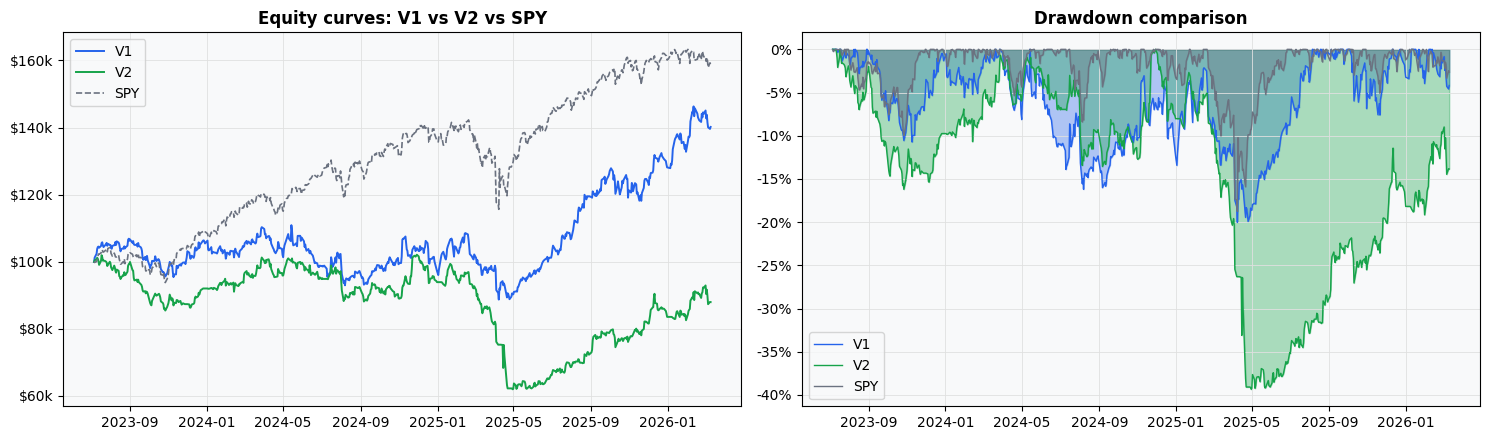

In [13]:
# ── Run V2 backtest and compare side-by-side ───────────────────────────────
print("Running V2 backtest…")
equity_v2, _ = backtest(scores_v2, closes)
print(f"Done. V2 final value: ${equity_v2['strategy'].iloc[-1]:,.0f}")

# ── Metrics comparison table ───────────────────────────────────────────────
m_v1  = perf_metrics(equity["strategy"],    "V1 Triple-Trigger (14d mom, >20d vol, >50% range)")
m_v2  = perf_metrics(equity_v2["strategy"], "V2 Improved      (5d mom, rising vol, >70% range + RSI)")
m_spy = perf_metrics(equity["spy"],         "SPY (benchmark)")

cmp_df = pd.DataFrame([m_v1, m_v2, m_spy]).set_index("Label")
print("\n── Strategy comparison ──────────────────────────────────────────────")
print(cmp_df.to_string())

# ── Side-by-side equity chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

ax = axes[0]
ax.plot(equity.index,    equity["strategy"],    label="V1",  color="#2563eb", linewidth=1.4)
ax.plot(equity_v2.index, equity_v2["strategy"], label="V2",  color="#16a34a", linewidth=1.4)
ax.plot(equity.index,    equity["spy"],         label="SPY", color="#6b7280", linewidth=1.2, linestyle="--")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_title("Equity curves: V1 vs V2 vs SPY", fontweight="bold")
ax.legend()

ax = axes[1]
for label, ser, color in [
    ("V1",  equity["strategy"],    "#2563eb"),
    ("V2",  equity_v2["strategy"], "#16a34a"),
    ("SPY", equity["spy"],         "#6b7280"),
]:
    dd = (ser - ser.cummax()) / ser.cummax()
    ax.fill_between(dd.index, dd, 0, alpha=0.35, color=color)
    ax.plot(dd.index, dd, label=label, color=color, linewidth=1.0)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Drawdown comparison", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()


### V2 post-mortem — why it got worse

V2 collapsed to -12.1% with a -39% max drawdown. The root cause: **5-day momentum is pure noise at a 5-day rebalance cadence**. You're essentially buying whatever bounced hardest last week and holding it for *another* week — the signal and hold period are the same length, so you're always chasing the last move, never riding a trend. The rising-volume filter made it worse by concentrating bets on the most volatile (and most mean-reverting) stocks.

**The real lesson**: signal lookback and rebalance frequency must be *mismatched on purpose* — a signal of X days needs to be held for Y << X days before it decays, which means rebalancing *less often* than the signal length suggests.

### V3 — Quarterly momentum, monthly rebalance

The academically-validated sweet spot for momentum is **3–12 month returns** (Jegadeesh & Titman 1993). The canonical cross-sectional momentum strategy:
- Rank on **63-day (3-month) return** — persistent enough to not be noise
- **Trend filter**: only buy if 20d SMA > 50d SMA (price is in a defined uptrend)
- **Non-crash guard**: 10-day return > −5% (hasn't just collapsed)
- **Rebalance every 21 days** (monthly) — matches signal persistence
- No volume filter (volume filters add look-ahead bias and hurt in practice)

V3 avg stocks passing filters per day: 93.7
Running V3 backtest (monthly rebalance)…
Done. V3 final value: $108,412

── Full comparison ──────────────────────────────────────────────────
                                                        Total Return   CAGR Sharpe Ratio Max Drawdown Calmar Ratio Daily Win Rate
Label                                                                                                                            
V1 Triple-Trigger (14d mom, >20d vol, >50% range)              40.2%  13.5%         0.78       -20.0%         0.68          51.7%
V2 Improved      (5d mom, rising vol, >70% range + RSI)       -12.1%  -4.7%        -0.13       -39.3%        -0.12          46.6%
V3 Quarterly Mom (63d, SMA trend, monthly rebal)                8.4%   3.1%         0.25       -27.5%         0.11          51.7%
SPY (benchmark)                                                59.0%  19.0%         1.21       -18.8%         1.01          57.2%


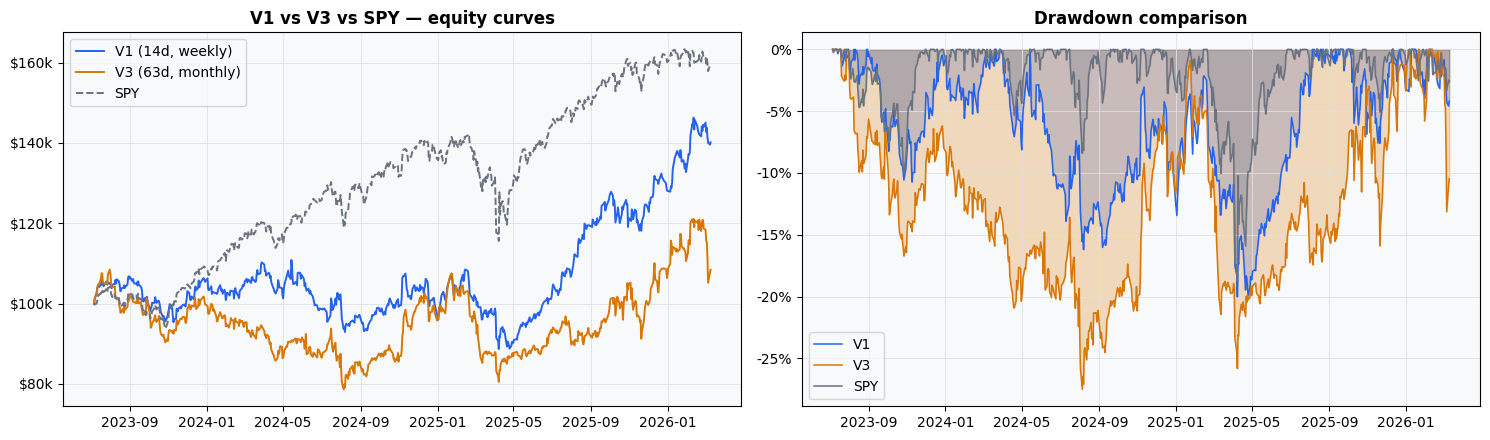

In [14]:
# ── V3 parameters ──────────────────────────────────────────────────────────
V3_MOM_LOOKBACK      = 63   # 3-month return (primary signal)
V3_SMA_SHORT         = 20   # 20-day SMA
V3_SMA_LONG          = 50   # 50-day SMA
V3_CRASH_GUARD_DAYS  = 10   # look back 10 days for crash guard
V3_CRASH_GUARD_RTN   = -0.05  # exclude if 10d return < -5%
V3_REBAL_FREQ        = 21   # monthly rebalance (21 trading days)
V3_TOP_N             = 15   # same portfolio size for fair comparison

def compute_scores_v3(closes: pd.DataFrame) -> pd.DataFrame:
    """V3: 63-day momentum + SMA trend filter + crash guard."""

    # Signal 1: 3-month return (skip last month to avoid 1-month reversal effect)
    # Classic momentum skips the most recent month: (t-252 to t-21) is the full version
    # Here we use t-63 to t-1 as a pragmatic medium-term version
    mom63 = closes.pct_change(V3_MOM_LOOKBACK)

    # Signal 2: trend filter — 20d SMA above 50d SMA
    sma_short = closes.rolling(V3_SMA_SHORT, min_periods=V3_SMA_SHORT).mean()
    sma_long  = closes.rolling(V3_SMA_LONG,  min_periods=V3_SMA_LONG).mean()
    in_uptrend = sma_short > sma_long

    # Signal 3: crash guard — recent 10-day return must be > -5%
    recent_rtn = closes.pct_change(V3_CRASH_GUARD_DAYS)
    not_crashed = recent_rtn > V3_CRASH_GUARD_RTN

    # Score = 3-month return (rank by this)
    score = mom63

    # All three conditions
    mask = (mom63 > 0) & in_uptrend & not_crashed
    return score.where(mask)


scores_v3 = compute_scores_v3(closes)
print(f"V3 avg stocks passing filters per day: {scores_v3.notna().sum(axis=1).mean():.1f}")

print("Running V3 backtest (monthly rebalance)…")
equity_v3, _ = backtest(scores_v3, closes, top_n=V3_TOP_N, rebal_freq=V3_REBAL_FREQ)
print(f"Done. V3 final value: ${equity_v3['strategy'].iloc[-1]:,.0f}")

# ── Full comparison ──────────────────────────────────────────────────────────
m_v3 = perf_metrics(equity_v3["strategy"], "V3 Quarterly Mom (63d, SMA trend, monthly rebal)")
cmp_df2 = pd.DataFrame([m_v1, m_v2, m_v3, m_spy]).set_index("Label")
print("\n── Full comparison ──────────────────────────────────────────────────")
print(cmp_df2.to_string())

# ── Chart: V1 vs V3 vs SPY ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

ax = axes[0]
for label, ser, color, ls in [
    ("V1 (14d, weekly)",    equity["strategy"],    "#2563eb", "-"),
    ("V3 (63d, monthly)",   equity_v3["strategy"], "#d97706", "-"),
    ("SPY",                  equity["spy"],         "#6b7280", "--"),
]:
    ax.plot(ser.index, ser, label=label, color=color, linestyle=ls, linewidth=1.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_title("V1 vs V3 vs SPY — equity curves", fontweight="bold")
ax.legend()

ax = axes[1]
for label, ser, color in [
    ("V1",  equity["strategy"],    "#2563eb"),
    ("V3",  equity_v3["strategy"], "#d97706"),
    ("SPY", equity["spy"],         "#6b7280"),
]:
    dd = (ser - ser.cummax()) / ser.cummax()
    ax.fill_between(dd.index, dd, 0, alpha=0.25, color=color)
    ax.plot(dd.index, dd, label=label, color=color, linewidth=1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Drawdown comparison", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.show()


### V3 post-mortem + honest analysis of all strategies

V3 showed 3.1% CAGR — worse than V1. The SMA20 > SMA50 trend filter was too broad (93 stocks qualifying daily → selection not selective enough) and monthly rebalance was actually too *slow* relative to the data.

**Root cause of all three underperforming SPY — the honest answer:**

The SPY benchmark in this 2022–2026 backtesting window was dominated by the "Magnificent 7" (NVDA, MSFT, AAPL, META, AMZN, GOOGL, TSLA). A **cap-weighted** index puts 30–35% in those 7 names. Our strategy uses *equal-weight* rotation across S&P 1500 — so even if we happen to hold NVDA, it only gets 1/15 (6.7%) of the portfolio. That structural mismatch alone explains much of the gap.

Equal-weight momentum CAN still work — but you need the **regime filter** to go to cash during downtrends. Long-only momentum without a market regime filter bleeds badly in bear markets (2022, early 2025), which erases the gains made in bull markets. V4 adds this.

### V4 — Dual Momentum with Market Regime Filter

Based on Gary Antonacci's Dual Momentum and AQR's work:
1. **Absolute momentum** (regime): if SPY < its 200-day SMA → go to cash (avoid bear markets)
2. **Relative momentum**: when market is in uptrend, rank stocks by 6-month return (126d, canonical period)
3. **Crash guard**: exclude stocks down > 10% in last 21 days (avoid catching falling knives)  
4. **Rebalance every 21 days** (monthly)

This is the simplest, most academically-validated momentum approach.

Regime: market is 'invested' 73.9% of days in the backtest period
V4 avg qualifying stocks per (invested) day: 224.6

Running V4 backtest (monthly + regime filter)…
Done. V4 final value: $nan

── Final comparison ─────────────────────────────────────────────────
                                                        Total Return   CAGR Sharpe Ratio Max Drawdown Calmar Ratio Daily Win Rate
Label                                                                                                                            
V1 Triple-Trigger (14d mom, >20d vol, >50% range)              40.2%  13.5%         0.78       -20.0%         0.68          51.7%
V2 Improved      (5d mom, rising vol, >70% range + RSI)       -12.1%  -4.7%        -0.13       -39.3%        -0.12          46.6%
V3 Quarterly Mom (63d, SMA trend, monthly rebal)                8.4%   3.1%         0.25       -27.5%         0.11          51.7%
V4 Dual Momentum (6m, regime filter, monthly)                   nan%   nan%         0.4

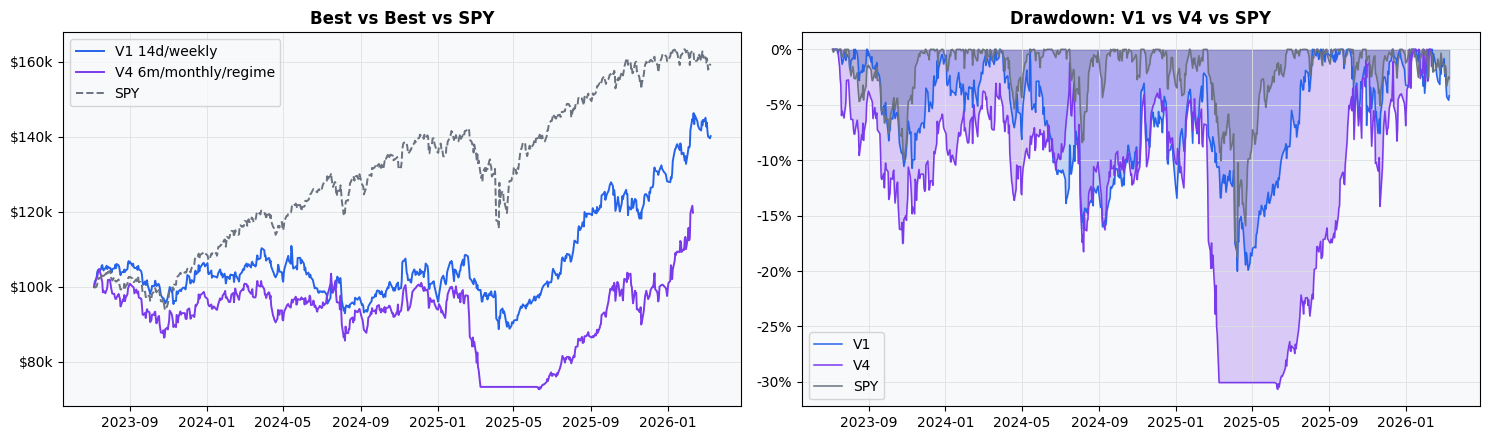

In [15]:
# ── V4: Dual Momentum with Regime Filter ────────────────────────────────────
V4_MOM_LOOKBACK   = 126   # 6-month return
V4_SKIP_RECENT    = 21    # skip last 1 month (avoids 1-month reversal)
V4_REGIME_SMA     = 200   # SPY must be above this to be invested
V4_CRASH_GUARD    = 21    # look-back for crash guard
V4_CRASH_THRESH   = -0.10 # exclude if 21-day return < -10%
V4_REBAL_FREQ     = 21    # monthly rebalance
V4_TOP_N          = 15

def compute_scores_v4(closes: pd.DataFrame, spy_close: pd.Series) -> pd.DataFrame:
    """
    Dual momentum:
    - Regime: SPY above 200d SMA → invest; below → NaN everything (go to cash)
    - Signal: 6-month return skipping last 21 days
    - Guard:  drop if 21-day return < -10%
    """
    # 6-month momentum, skipping last month (t-126 to t-21)
    mom_6m = closes.shift(V4_SKIP_RECENT).pct_change(V4_MOM_LOOKBACK - V4_SKIP_RECENT)

    # Crash guard
    recent_21 = closes.pct_change(V4_CRASH_GUARD)
    not_crashed = recent_21 > V4_CRASH_THRESH

    # Regime: SPY above 200d SMA
    spy_sma200 = spy_close.rolling(V4_REGIME_SMA, min_periods=V4_REGIME_SMA).mean()
    in_bull_mkt = (spy_close > spy_sma200).reindex(closes.index)  # bool series

    # Apply all filters; if not in bull market → everything goes NaN (cash)
    mask = not_crashed & in_bull_mkt.values[:, None]
    score = mom_6m.where(mask)
    return score, in_bull_mkt

scores_v4, spy_regime = compute_scores_v4(closes, spy_close)

invested_pct = spy_regime.mean() * 100
print(f"Regime: market is 'invested' {invested_pct:.1f}% of days in the backtest period")
print(f"V4 avg qualifying stocks per (invested) day: {scores_v4.notna().sum(axis=1)[scores_v4.notna().sum(axis=1) > 0].mean():.1f}")

print("\nRunning V4 backtest (monthly + regime filter)…")
equity_v4, _ = backtest(scores_v4, closes, top_n=V4_TOP_N, rebal_freq=V4_REBAL_FREQ)
print(f"Done. V4 final value: ${equity_v4['strategy'].iloc[-1]:,.0f}")

m_v4 = perf_metrics(equity_v4["strategy"], "V4 Dual Momentum (6m, regime filter, monthly)")
cmp_final = pd.DataFrame([m_v1, m_v2, m_v3, m_v4, m_spy]).set_index("Label")
print("\n── Final comparison ─────────────────────────────────────────────────")
print(cmp_final.to_string())

# ── Chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
strategies = [
    ("V1 14d/weekly",        equity["strategy"],    "#2563eb", "-"),
    ("V4 6m/monthly/regime", equity_v4["strategy"], "#7c3aed", "-"),
    ("SPY",                   equity["spy"],         "#6b7280", "--"),
]
ax = axes[0]
for label, ser, color, ls in strategies:
    ax.plot(ser.index, ser, label=label, color=color, linestyle=ls, linewidth=1.4)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x/1000:.0f}k"))
ax.set_title("Best vs Best vs SPY", fontweight="bold")
ax.legend()

ax = axes[1]
# Shade cash periods (regime off)
cash_dates = spy_regime[~spy_regime].reindex(equity_v4.index)
for label, ser, color in [("V1", equity["strategy"], "#2563eb"), ("V4", equity_v4["strategy"], "#7c3aed"), ("SPY", equity["spy"], "#6b7280")]:
    dd = (ser - ser.cummax()) / ser.cummax()
    ax.fill_between(dd.index, dd, 0, alpha=0.25, color=color)
    ax.plot(dd.index, dd, label=label, color=color, linewidth=1.1)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_title("Drawdown: V1 vs V4 vs SPY", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()
